In [3]:
import matplotlib.pyplot as plt
import numpy as np
import nnfs
from nnfs.datasets import vertical_data
nnfs.init()

In [4]:
class Layer_Dense():
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    def forward(self, inputs):
        self.output = np.dot(inputs, self.weights) + self.biases

In [5]:
class Activation_ReLU():
    def forward(self, inputs):
        self.output = np.maximum(0, inputs)

In [6]:
class Activation_Softmax():
    def forward(self, inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True)
        self.output = probabilities

In [7]:
class Loss():
    def calculate(self, output, y):
        sample_losses = self.forward(output, y)
        data_loss = np.mean(sample_losses)
        return data_loss

In [8]:
class Loss_CCE(Loss):
    def forward(self, y_pred, y_true):
        samples = len(y_pred)
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[
            range(samples),
            y_true
        ]
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(
            y_pred_clipped*y_true,
            axis=1
        )
        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods

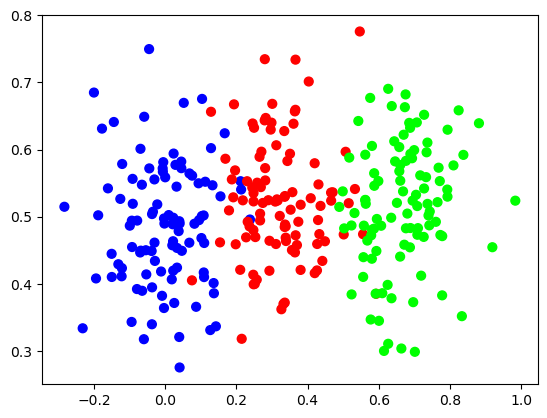

In [10]:
X, y = vertical_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='brg')
plt.show()

In [9]:
X, y = vertical_data(samples=100, classes=3)
# Create model
dense1 = Layer_Dense(2, 3) # first dense layer, 2 inputs
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3, 3) # second dense layer, 3 inputs, 3 outputs
activation2 = Activation_Softmax()
# Create loss function
loss_function = Loss_CCE()

In [11]:
lowest_loss = 9999999 # some initial value
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()

In [14]:
for iteration in range(10000):
    # Update weights with some small random values
    dense1.weights += 0.05 * np.random.randn(2, 3)
    dense1.biases += 0.05 * np.random.randn(1, 3)
    dense2.weights += 0.05 * np.random.randn(3, 3)
    dense2.biases += 0.05 * np.random.randn(1, 3)
    # Perform a forward pass of our training data through this layer
    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    activation2.forward(dense2.output)
    # Perform a forward pass through activation function
    # it takes the output of second dense layer here and returns loss
    loss = loss_function.calculate(activation2.output, y)
    # Calculate accuracy from output of activation2 and targets
# calculate values along first axis
    predictions = np.argmax(activation2.output, axis=1)
    accuracy = np.mean(predictions == y)
    # If loss is smaller - print and save weights and biases aside
    if loss < lowest_loss:
        print('New set of weights found, iteration:', iteration,
        'loss:', loss, 'acc:', accuracy)
        best_dense1_weights = dense1.weights.copy()
        best_dense1_biases = dense1.biases.copy()
        best_dense2_weights = dense2.weights.copy()
        best_dense2_biases = dense2.biases.copy()
        lowest_loss = loss
    # Revert weights and biases
    else:
        dense1.weights = best_dense1_weights.copy()
        dense1.biases = best_dense1_biases.copy()
        dense2.weights = best_dense2_weights.copy()
        dense2.biases = best_dense2_biases.copy()

New set of weights found, iteration: 1 loss: 1.0922511 acc: 0.49333333333333335
New set of weights found, iteration: 4 loss: 1.0916764 acc: 0.3333333333333333
New set of weights found, iteration: 5 loss: 1.0891631 acc: 0.33666666666666667
New set of weights found, iteration: 11 loss: 1.0863658 acc: 0.3333333333333333
New set of weights found, iteration: 14 loss: 1.0845863 acc: 0.3333333333333333
New set of weights found, iteration: 15 loss: 1.0842602 acc: 0.3333333333333333
New set of weights found, iteration: 16 loss: 1.0799417 acc: 0.33666666666666667
New set of weights found, iteration: 18 loss: 1.0755546 acc: 0.5933333333333334
New set of weights found, iteration: 20 loss: 1.0683032 acc: 0.33666666666666667
New set of weights found, iteration: 21 loss: 1.0621961 acc: 0.3333333333333333
New set of weights found, iteration: 22 loss: 1.059188 acc: 0.3333333333333333
New set of weights found, iteration: 28 loss: 1.0590912 acc: 0.3333333333333333
New set of weights found, iteration: 32 